In [25]:
import os
import math
import cv2
import pytesseract
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

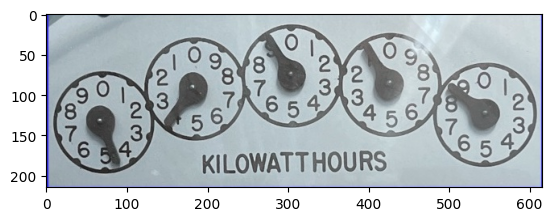

In [26]:
#img = cv2.imread('../data/dial_Enertiv_annotated/264.jpg')
img = cv2.imread('264_cropped.jpg')
expected_value = 19193
plt.imshow(img)

In [27]:
CCW_value_ranges = {
    0: [90, 126],
    1: [126, 162],
    2: [162, 198],
    3: [198, 234],
    4: [234, 270],
    5: [270, 306],
    6: [306, 342],
    7: [342, 18],
    8: [18, 54],
    9: [54, 90]
}

CW_value_ranges = {
    0: [90, 54],
    1: [54, 18],
    2: [18, 342],
    3: [342, 306],
    4: [306, 270],
    5: [270, 234],
    6: [234, 198],
    7: [198, 162],
    8: [162, 126],
    9: [126, 90]
}

In [28]:
def getValue(val: int, is_clockwise: bool) -> float:
    if is_clockwise:
        value = val
    else:
        value = 10. - val
    if value == 10:
        value = 0
    return value

In [29]:
def Preprocess(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gaussian_gray = cv2.GaussianBlur(gray, (5, 5), 0)
    return gray, gaussian_gray

In [30]:
def DialDetector(image, gaussian_gray):

    # find the circles
    circles = cv2.HoughCircles(gaussian_gray, cv2.HOUGH_GRADIENT, dp=1, minDist=45, param1=150, param2=90, minRadius=0, maxRadius=0)
    # round all x, y, r values
    circles = np.uint16(np.around(circles))
    
    # print("np array of circles (x, y, r)")
    # print(circles)
    # print(type(circles))
    
    # Sort the circles from left to right (smallest to largest x-value)
    # print("\nnp array of circles (x, y, r): sorted")
    circles = circles[0][np.argsort(circles[:, :, 0])]
    # print(circles)
    # print(type(circles), "\n")
    
    # draw the circles
    for i in circles[0][:5]:
        # draws the outer part of the circle
        cv2.circle(image,(i[0],i[1]),i[2],(0,255,0),2)
        # draws the center of the circle
        cv2.circle(image,(i[0],i[1]),2,(0,0,255),3)
   
    return circles

In [31]:
# inspiration for this function: 
# https://github.com/mirogta/dial-meter-reader-opencv-py

def getPointer(x: int, y: int, r: int, image) -> tuple:
    slices = 40 # = 36
    size = r * 0.8
    factor = 360/slices
    pointer = None
    longest_dark = 0
    value = None
    center = tuple([x,y])
    for i in range(slices):
        angle = i*factor-90
        dark_length = 0
        x2 = x + int(size*np.cos(angle*np.pi/180))
        y2 = y + int(size*np.sin(angle*np.pi/180))
        points_on_line = np.linspace(center, (x2,y2), 255, 2)
        for p in points_on_line:
            point = np.int32(p)
            px = point[0]
            py = point[1]
            b = image[:, :, 0][py, px]
            g = image[:, :, 1][py, px]
            r = image[:, :, 2][py, px]
            gray = (b.astype(int) + g.astype(int) + r.astype(int))/3
            if gray < 130:
                dark_length += 1
            else:
                continue
        if dark_length > longest_dark:
            longest_dark = dark_length
            pointer = tuple(point)
            value = 10*i/slices
    return value, pointer

In [32]:
# inspiration for this function: 
# https://github.com/mirogta/dial-meter-reader-opencv-py

def ProcessValues(values) -> str:
    meter_value = ""
    # for val in reversed(values):
    #     value, next_value = val, next(val)

    for i, (v) in enumerate(values):
        whole = int(np.floor(v))
        if i == len(values) - 1:
            meter_value += str(whole)
            break
        decimals = v - whole
        if decimals < 0.5 and values[i+1] > 5:
            whole -= 1
        meter_value += str(whole)
    return meter_value

In [33]:
def getDialOrientation(circles, image) -> bool:
    is_clockwise: bool
    circle = circles[0][0]
    x, y, r = circle
    #img2 = cv2.imread("264_cropped.jpg")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 9, 9)

    #thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    mask = np.zeros_like(thresh)
    cv2.circle(mask, (x,y), r, 255, -1)
    thresh = cv2.bitwise_and(thresh, mask)

    # kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3), -1)
    # closed = cv2.morphologyEx(thresh, cv2.MORPH_BLACKHAT, kernel)

    #cv2.imwrite("first_dial_thresh.png", thresh)
    x1 = int(x - r)
    x2 = int(x + r)
    y1 = int(y - r)
    y2 = int(y + r)

    cropped = thresh[y1:y2, x1:x2]
    resized = cv2.resize(cropped, (150, 150))
    cv2.imwrite("cropped_dial.png", resized)
    
    roi1 = resized[y1:y2, x1:x]
    roi2 = resized[y1:y2, x:x2]
    
    region1 = pytesseract.image_to_string(roi1, config='--psm 11 --oem 3 -c tessedit_char_whitelist=12346789')
    region2 = pytesseract.image_to_string(roi2, config='--psm 11 --oem 3 -c tessedit_char_whitelist=12346789')

    # region1 = pytesseract.image_to_data(roi1, output_type='data.frame')
    # region2 = pytesseract.image_to_data(roi2, output_type='data.frame')

    # region1 = region1[region1.conf != -1]
    # region1.head()
    # nums1 = region1.groupby(['page_num','block_num', 'par_num', 'line_num'])['text'].apply(lambda x: ' '.join(list(x))).tolist()
    # conf1 = region1.groupby(['page_num', 'block_num', 'par_num', 'line_num'])['conf'].mean().tolist()
    # line_conf1 = []
    # for i in range(len(nums1)):
    #     if nums1[i].strip():
    #         line_conf1.append((nums1[i, round(conf1[i],3)]))
    # print(line_conf1)

    print("REGION 1 (LEFT)", region1)
    print("REGION 2 (right)", region2)

    # region2 = region2[region2.conf != -1]
    # region2.head()
    # nums2 = region2.groupby(['page_num','block_num', 'par_num', 'line_num'])['text'].apply(lambda y: ' '.join(list(y))).tolist()
    # conf2 = region2.groupby(['page_num', 'block_num', 'par_num', 'line_num'])['conf'].mean().tolist()
    # line_conf2 = []
    # for i in range(len(nums2)):
    #     if nums2[i].strip():
    #         line_conf2.append((nums2[i, round(conf2[i],3)]))
    # print(line_conf2)

    if any(digit in region1 for digit in ['1', '2', '3', '4']) or any(digit in region2 for digit in ['6', '7', '8', '9']):
        is_clockwise = False
    elif any(digit in region2 for digit in ['1', '2', '3', '4']) or any(digit in region1 for digit in ['6', '7', '8', '9']):
        is_clockwise = True
    else:
        return True
    return is_clockwise
    

In [34]:
def MeterValue(circles, image) -> str:
    values = []
    #is_clockwise = getDialOrientation(circles, image)
    if getDialOrientation(circles, image):
        i = 0
    else:
        i = 1
    for c in circles[0]:
        
        x, y, r = c[0], c[1], c[2]

        val, tip = getPointer(x=x, y=y, r=r, image=image)
        angle = np.rad2deg(np.arctan2(-(tip[1]-y), tip[0]-x))
        if angle < 0:
            angle += 360.0
        cv2.putText(image, str(int(angle)), (int(x) + 10, int(y)), cv2.FONT_HERSHEY_SCRIPT_SIMPLEX, 0.5, (0, 0, 255), 2)
        # draws line on the dial pointer
        cv2.line(image, (x, y), tip, (255, 0, 0), 2)

        if i % 2 == 0:
            print(f"Dial {i}:", f"value = {getValue(val=val, is_clockwise=True)}")
            values.append(getValue(val=val, is_clockwise=True))
        else:
            print(f"Dial {i}:", f"value = {getValue(val=val, is_clockwise=False)}")
            values.append(getValue(val=val, is_clockwise=False))
    
        i += 1
    
    return ProcessValues(values)

REGION 1 (LEFT) 6

REGION 2 (right) 
Dial 0: value = 4.5
Dial 1: value = 4.25
Dial 2: value = 9.0
Dial 3: value = 1.0
Dial 4: value = 8.5
meter value: 43908 kWh
expected value: 19193 kWh


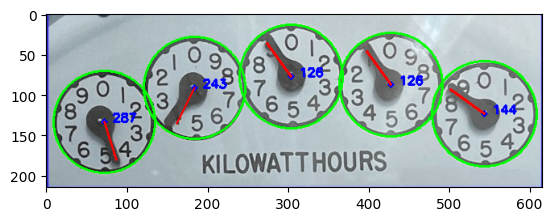

In [35]:
gray, gaussian_gray = Preprocess(img)
dials = DialDetector(img, gaussian_gray)
meter_value = int(MeterValue(dials, img))
print(f"meter value: {meter_value} kWh")
print(f"expected value: {expected_value} kWh")

plt.imshow(img)

    level  page_num  block_num  par_num  line_num  word_num  left  top  width  \
4       5         1          1        1         1         1   419   36     42   
8       5         1          2        1         1         1    37   83     60   
12      5         1          3        1         1         1   105   98     47   
16      5         1          4        1         1         1   203   50     31   
20      5         1          5        1         1         1   273   26     67   
24      5         1          6        1         1         1   394  112     68   

    height       conf text  
4       29   0.000000    9  
8       29   0.000000   99  
12      33   0.000000    3  
16      87  38.947914    4  
20     104   0.000000    .  
24      29   0.000000  466  
block_num
1      [9]
2     [99]
3      [3]
4      [4]
5      [.]
6    [466]
Name: text, dtype: object
block_num
1     0.000000
2     0.000000
3     0.000000
4    38.947914
5     0.000000
6     0.000000
Name: conf, dtype: float64


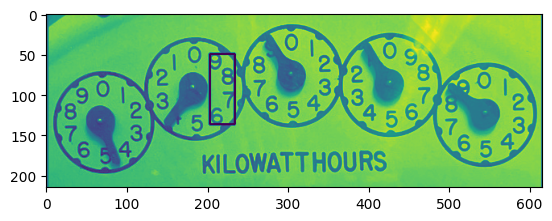

In [36]:
# # edges = cv2.Canny(gray, 50, 150, apertureSize=3)
# # lines = cv2.HoughLines(edges, rho=1, theta=np.pi/180, threshold=100)
# # angles = []
# # for line in lines:
# #     rho, theta = line[0]
# #     angle = theta * 180 / np.pi
# #     angles.append(angle)

# # orientation = None
# # direction = None
# # if np.mean(angles) < 45 or np.mean(angles) > 135:
# #     orientation = 'vertical'
# #     if np.mean(angles) < 45:
# #         direction = 'clockwise'
# #     else:
# #         direction = 'counterclockwise'
# # else:
# #     orientation = 'horizontal'
# #     if np.mean(angles) < 90:
# #         direction = 'counterclockwise'
# #     else:
# #         direction = 'clockwise'

# # print('dial orientation', orientation)
# # print('dial direction', direction)


# ccw_cropped = cv2.imread('dialmeter1_counterclockwise.jpeg')
# cw_cropped = cv2.imread('dialmeter1_clockwise.jpeg')


# ccw_template = cv2.imread('counterclockwise_template.png')
# cw_template = cv2.imread('clockwise_template.png')
# #plt.imshow(cw_template)

# # ccw_gray = cv2.cvtColor(ccw_cropped, cv2.COLOR_BGR2GRAY)
# # ccw_template_gray = cv2.cvtColor(ccw_template, cv2.COLOR_BGR2GRAY)
# dial_height, dial_width, _ = cw_cropped.shape

# # h, w = ccw_template_gray.shape
# # res = cv2.matchTemplate(ccw_gray, ccw_template_gray, cv2.TM_CCOEFF_NORMED)
# # min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
# # if max_loc[0] < ccw_gray.shape[1]/2 and max_loc[1] < ccw_gray.shape[0]/2:
# #     orientation = 'clockwise'
# # else:
# #     orientation = 'counterclockwise'

# cw_gray = cv2.cvtColor(cw_cropped, cv2.COLOR_BGR2GRAY)
# cw_template_gray = cv2.cvtColor(cw_template, cv2.COLOR_BGR2GRAY)
# ccw_template_gray = cv2.cvtColor(ccw_template, cv2.COLOR_BGR2GRAY)
# cw_t_resized = cv2.resize(cw_template_gray, (dial_width, dial_height))
# ccw_t_resized = cv2.resize(ccw_template_gray, (dial_width, dial_height))
# plt.imshow(cw_gray)
# # h, w = cw_template_gray.shape
# # res = cv2.matchTemplate(cw_gray, cw_template_gray, cv2.TM_CCOEFF_NORMED)
# # min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
# # if max_loc[0] < cw_gray.shape[1]/2 and max_loc[1] < cw_gray.shape[0]/2:
# #     orientation = 'clockwise'
# # else:
# #     orientation = 'counterclockwise'
# # print(orientation)
# max_score_clockwise = -1
# max_score_counterclockwise = -1
# digit_clockwise = -1
# digit_counterclockwise = -1
# for i in range(10):
#     res_clockwise = cv2.matchTemplate(cw_gray, cw_t_resized, cv2.TM_CCOEFF_NORMED)
#     res_counterclockwise = cv2.matchTemplate(cw_gray, ccw_t_resized, cv2.TM_CCOEFF_NORMED)
#     score_clockwise = np.max(res_clockwise)
#     score_counterclockwise = np.max(res_counterclockwise)
#     if score_clockwise > max_score_clockwise:
#         max_score_clockwise = score_clockwise
#         digit_clockwise = i
#     if score_counterclockwise > max_score_counterclockwise:
#         max_score_counterclockwise = score_counterclockwise
#         digit_counterclockwise = i

# if max_score_clockwise > max_score_counterclockwise:
#     orientation = "clockwise"
#     digit = digit_clockwise
# else:
#     orientation = "counterclockwise"
# print(orientation)

img5 = cv2.imread('264_cropped.jpg')
#img5 = Image.open('264_cropped.jpg')
img5 = cv2.cvtColor(img5, cv2.COLOR_BGR2GRAY)
text1 = pytesseract.image_to_data(img5, config='--psm 11 --oem 3 -c tessedit_char_whitelist=12346789.', output_type='data.frame')

text = text1[text1.conf != -1]
lines = text.groupby('block_num')['text'].apply(list)
conf = text.groupby(['block_num'])['conf'].mean()

print(text)
print(lines)
print(conf)

n_boxes = len(text1['text'])
for i in range(n_boxes):
    if int(text1['conf'][i]) > 20:
        (x, y, w, h) = (text1['left'][i], text1['top'][i], text1['width'][i], text1['height'][i])
        cv2.rectangle(img5, (x, y), (x + w, y + h), (0, 255, 0), 2)

plt.imshow(img5)
